In [ ]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle-3.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d vibhingupta028/liver-histopathology-fibrosis-ultrasound-images
!unzip -q liver-histopathology-fibrosis-ultrasound-images.zip -d liver

!pip install thop torchsummary -q

Saving kaggle-3.json to kaggle-3.json
Dataset URL: https://www.kaggle.com/datasets/vibhingupta028/liver-histopathology-fibrosis-ultrasound-images
License(s): CC-BY-SA-4.0
 82% 167M/205M [00:00<00:00, 1.75GB/s]
100% 205M/205M [00:00<00:00, 1.75GB/s]


In [ ]:
import os
import random
import math
import time
import json
import numpy as np
import pandas as pd
from PIL import Image
import cv2
import matplotlib.pyplot as plt

from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR

import torchvision.transforms as transforms


from sklearn.model_selection import train_test_split, StratifiedKFold


from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, accuracy_score

from thop import profile
from torchsummary import summary
from collections import defaultdict


In [ ]:
RANDOM_STATE = 42

def make_everything_deterministic(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    torch.use_deterministic_algorithms(True, warn_only=True)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.enabled = True

    torch.backends.cuda.matmul.fp32_precision = "ieee"
    torch.backends.cudnn.conv.fp32_precision = "ieee"



def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def build_generator(seed=42):
    g = torch.Generator()
    g.manual_seed(seed)
    return g


make_everything_deterministic(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

num_workers = os.cpu_count()
print("Num workers:", num_workers)


Device: cuda
Num workers: 12


In [ ]:
!ls liver/Dataset/Dataset

F0  F1	F2  F3	F4


In [ ]:
%%shell
for dir in liver/Dataset/Dataset/*; do
  echo "$(basename "$dir"): $(ls -1 "$dir" | wc -l) images"
done

F0: 2114 images
F1: 861 images
F2: 793 images
F3: 857 images
F4: 1698 images


In [ ]:
DATA_ROOT = "/content/liver/Dataset/Dataset"

for cls in sorted(os.listdir(DATA_ROOT)):
    cls_path = os.path.join(DATA_ROOT, cls)
    if not os.path.isdir(cls_path):
        continue

    exts = []
    for f in os.listdir(cls_path):
        if os.path.isfile(os.path.join(cls_path, f)):
            ext = os.path.splitext(f)[1].lower()
            exts.append(ext)

    counter = Counter(exts)
    print(f"\n{cls}:")
    for ext, count in counter.most_common():
        print(f"  {ext}: {count}")


F0:
  .jpg: 2114

F1:
  .jpg: 685
  .png: 176

F2:
  .jpg: 485
  .png: 308

F3:
  .jpg: 549
  .png: 308

F4:
  .jpg: 1564
  .png: 134


In [ ]:
DATA_ROOT = "/content/liver/Dataset/Dataset"
VALID_EXTS = (".jpg", ".jpeg", ".png")

RANDOM_STATE = 42
BATCH_SIZE = 32

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.10
TEST_RATIO  = 0.20

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9, "Ratios must sum to 1.0"

In [ ]:
filepaths = []
labels = []

for root, _, files in os.walk(DATA_ROOT):
    for file in files:
        if file.lower().endswith(VALID_EXTS):
            full_path = os.path.join(root, file)

            # Label = parent folder name (F0, F1, ...)
            label = os.path.basename(os.path.dirname(full_path))

            filepaths.append(full_path)
            labels.append(label)

df = pd.DataFrame({"filename": filepaths, "label": labels})

if len(df) == 0:
    raise RuntimeError(f"No images found in: {DATA_ROOT}")

print("Total images:", len(df))
print("\nOverall class distribution:\n", df["label"].value_counts())


Total images: 6323

Overall class distribution:
 label
F0    2114
F4    1698
F1     861
F3     857
F2     793
Name: count, dtype: int64


In [ ]:
df = df.sort_values("filename").reset_index(drop=True)

TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10

train_val_df, test_df = train_test_split(
    df,
    test_size=TEST_RATIO,
    stratify=df["label"],
    random_state=RANDOM_STATE
)


val_size = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_size,
    stratify=train_val_df["label"],
    random_state=RANDOM_STATE
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)


train_set = set(train_df["filename"])
val_set   = set(val_df["filename"])
test_set  = set(test_df["filename"])

assert len(train_set & val_set) == 0, "Train/Val overlap detected!"
assert len(train_set & test_set) == 0, "Train/Test overlap detected!"
assert len(val_set & test_set) == 0, "Val/Test overlap detected!"


train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("\n✔ Saved: train.csv, val.csv, test.csv")



✔ Saved: train.csv, val.csv, test.csv


In [ ]:
all_labels = sorted(df["label"].unique())
label_to_idx = {label: idx for idx, label in enumerate(all_labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

print("\nLabel mapping:", label_to_idx)


Label mapping: {'F0': 0, 'F1': 1, 'F2': 2, 'F3': 3, 'F4': 4}


In [ ]:
class CustomImageDataset(Dataset):
    def __init__(self, df, label_to_idx, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_to_idx = label_to_idx
        self.num_classes = len(label_to_idx)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "filename"]
        label_str = self.df.loc[idx, "label"]

        image = Image.open(img_path).convert("RGB")
        label_idx = self.label_to_idx[label_str]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label_idx, dtype=torch.long)

In [ ]:
def compute_dataset_stats(loader):
    mean = torch.zeros(3)
    var = torch.zeros(3)
    n_pixels = 0

    for images, _ in tqdm(loader, desc="Computing stats", unit="batch"):
        b, c, h, w = images.shape
        pixels = b * h * w

        mean += images.sum(dim=[0, 2, 3])
        var += (images ** 2).sum(dim=[0, 2, 3])

        n_pixels += pixels

    mean /= n_pixels
    var = (var / n_pixels) - (mean ** 2)
    std = torch.sqrt(var.clamp(min=1e-8))

    return mean, std


all_labels = sorted(train_df["label"].unique())
label_to_idx = {label: idx for idx, label in enumerate(all_labels)}

print("Label mapping:", label_to_idx)


temp_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

temp_dataset = CustomImageDataset(train_df, label_to_idx, transform=temp_transform)

temp_loader = DataLoader(
    temp_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

print("Computing mean & std...")
mean, std = compute_dataset_stats(temp_loader)

print(f"Dataset-specific mean: {mean.tolist()}")
print(f"Dataset-specific std:  {std.tolist()}")

Label mapping: {'F0': 0, 'F1': 1, 'F2': 2, 'F3': 3, 'F4': 4}
Computing mean & std...


Computing stats: 100%|██████████| 80/80 [00:05<00:00, 13.56batch/s]

Dataset-specific mean: [0.11523187905550003, 0.11523187905550003, 0.11523187905550003]
Dataset-specific std:  [0.14941120147705078, 0.14941120147705078, 0.14941120147705078]


In [ ]:
def mixup(data, targets, alpha=0.2, mixup_prob=0.5):
    """
    data:    (B, C, H, W)
    targets: class indices (B,)
    """
    if np.random.rand() > mixup_prob:
        return data, targets, targets, 1.0

    batch_size = data.size(0)
    lam = np.random.beta(alpha, alpha)
    indices = torch.randperm(batch_size).to(data.device)

    mixed_data = lam * data + (1 - lam) * data[indices]
    targets_a = targets
    targets_b = targets[indices]

    return mixed_data, targets_a, targets_b, lam


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    transforms.RandomResizedCrop(
        224, scale=(0.85, 1.0), ratio=(0.9, 1.1)
    ),
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomAffine(
        degrees=10,
        translate=(0.06, 0.06),
        scale=(0.93, 1.07),
        shear=3
    ),

    transforms.RandomApply(
        [transforms.GaussianBlur(3, sigma=(0.3, 0.9))],
        p=0.1
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])



test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [ ]:
train_dataset = CustomImageDataset(train_df, label_to_idx, transform=train_transform)
val_dataset   = CustomImageDataset(val_df, label_to_idx, transform=test_transform)
test_dataset  = CustomImageDataset(test_df, label_to_idx, transform=test_transform)

In [ ]:
class_counts = train_df["label"].value_counts()

counts = torch.zeros(len(label_to_idx), dtype=torch.float)
for label, idx in label_to_idx.items():
    counts[idx] = class_counts[label]


class_weights = 1.0 / counts

sample_weights = torch.tensor(
    [class_weights[label_to_idx[label]] for label in train_df["label"]],
    dtype=torch.float
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("\n✔ WeightedRandomSampler enabled (train only).")


✔ WeightedRandomSampler enabled (train only).


In [ ]:
g = build_generator(RANDOM_STATE)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,                 
    shuffle=False,                   
    num_workers=num_workers,
    worker_init_fn=seed_worker,
    generator=g,
    pin_memory=True,
    persistent_workers=True if num_workers > 0 else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    worker_init_fn=seed_worker,
    generator=g,
    pin_memory=True,
    persistent_workers=True if num_workers> 0 else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    worker_init_fn=seed_worker,
    generator=g,
    pin_memory=True,
    persistent_workers=True if num_workers > 0 else False
)

print("\n✔ DataLoaders ready!")
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))


✔ DataLoaders ready!
Train batches: 159
Val batches  : 20
Test batches : 20


In [ ]:
# Basic Residual Block for ResNet-18
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):

        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity  
        out = self.relu(out)
        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.in_channels = 64

    
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

 
        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)



        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * BasicBlock.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * BasicBlock.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * BasicBlock.expansion)
            )
        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * BasicBlock.expansion
        for _ in range(1, blocks):
            layers.append(BasicBlock(self.in_channels, out_channels))
        return nn.Sequential(*layers)



    def forward(self, x):


        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

In [ ]:
model = ResNet18(num_classes=5) 
print(model)

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)


In [ ]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

params = count_params(model)

print(f"Parameters: {params:,}")
print(f"Parameters (M): {params/1e6:.4f} M")


Parameters: 11,179,077
Parameters (M): 11.1791 M


In [ ]:
input_tensor = torch.randn(1, 3, 224, 224).to(device)

flops, params = profile(model, inputs=(input_tensor,), verbose=False)

print(f"FLOPs: {flops/1e9:.4f} GFLOPs")
print(f"Params: {params/1e6:.4f} M")

FLOPs: 1.8235 GFLOPs
Params: 11.1791 M


In [ ]:
def train_model(model, train_loader, val_loader, num_epochs=50, save_path="best_model.pth"):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=1e-4,
        weight_decay=1e-4,
        betas=(0.9, 0.999),
        eps=1e-8
    )

    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)


    train_loss_history, val_loss_history = [], []
    train_acc_history, val_acc_history = [], []
    val_precision_history, val_recall_history, val_f1_history = [], [], []
    val_specificity_history, val_auc_history = [], []


    best_val_loss = float("inf")
    best_epoch = 0

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    for epoch in range(num_epochs):
        start_time = time.time()


        model.train()
        running_loss = 0.0
        correct_train, total_train = 0, 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()


            inputs, targets_a, targets_b, lam = mixup(
                inputs,
                labels,
                alpha=0.1,
                mixup_prob=0.15
            )

            outputs = model(inputs)

            loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            preds = outputs.argmax(dim=1)

            correct_train += (
                lam * (preds == targets_a).sum().item()
                + (1 - lam) * (preds == targets_b).sum().item()
            )

            total_train += labels.size(0)

        train_loss = running_loss / total_train if total_train > 0 else 0.0
        train_acc = correct_train / total_train if total_train > 0 else 0.0

        train_loss_history.append(train_loss)
        train_acc_history.append(train_acc)


        model.eval()
        val_loss = 0.0
        correct_val, total_val = 0, 0
        all_preds, all_labels, all_probs = [], [], []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)

                preds = outputs.argmax(dim=1)
                probs = torch.softmax(outputs, dim=1)

                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        val_loss = val_loss / total_val if total_val > 0 else 1.0
        val_acc = correct_val / total_val if total_val > 0 else 0.0

        # ===================== Metrics =====================
        val_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
        val_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
        val_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

        cm = confusion_matrix(all_labels, all_preds)
        specificity_per_class = []

        for i in range(len(cm)):
            tn = cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]
            fp = cm[:, i].sum() - cm[i, i]
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            specificity_per_class.append(specificity)

        binc = np.bincount(all_labels)
        if len(binc) == len(specificity_per_class) and binc.sum() > 0:
            val_specificity = np.average(specificity_per_class, weights=binc)
        else:
            val_specificity = float(np.mean(specificity_per_class))

        try:
            if len(np.unique(all_labels)) == 2:
                positive_probs = [p[1] for p in all_probs]
                val_auc = roc_auc_score(all_labels, positive_probs)
            else:
                val_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')
        except ValueError:
            val_auc = 0.0

        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc)
        val_precision_history.append(val_precision)
        val_recall_history.append(val_recall)
        val_f1_history.append(val_f1)
        val_specificity_history.append(val_specificity)
        val_auc_history.append(val_auc)


        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            torch.save(model.state_dict(), save_path)
            print(f"New best model saved at epoch {best_epoch} with val_loss: {best_val_loss:.4f}")
            print(f"Confusion Matrix (Val):\n{cm}")

        scheduler.step()
        epoch_duration = time.time() - start_time


        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train: Loss={train_loss:.4f}, Acc={train_acc*100:.2f}%")
        print(f"Val: Loss={val_loss:.4f}, Acc={val_acc*100:.2f}%, "
              f"Precision={val_precision*100:.2f}%, Recall={val_recall*100:.2f}%, "
              f"Specificity={val_specificity*100:.2f}%, F1={val_f1*100:.2f}%, AUC={val_auc*100:.2f}%")
        print(f"LR: {scheduler.get_last_lr()[0]:.6f}")
        print(f"Epoch duration: {epoch_duration:.2f} seconds")
        print("*" * 100)

    print(f"Best model was from epoch {best_epoch} with val_loss: {best_val_loss:.4f}, saved to '{save_path}'")

    return (
        train_loss_history, val_loss_history,
        train_acc_history, val_acc_history,
        val_precision_history, val_recall_history,
        val_specificity_history, val_f1_history,
        val_auc_history
    )


In [ ]:
train_loss_history, val_loss_history, train_acc_history, val_acc_history, val_precision_history, val_recall_history, val_specificity_history, val_f1_history, val_auc_history = train_model(
    model, train_loader, val_loader, num_epochs=50, save_path="best_model.pth"
)

New best model saved at epoch 1 with val_loss: 1.8752
Confusion Matrix (Val):
[[ 15  29   0  14 154]
 [  0   0   1  62  23]
 [  0   0   8  71   0]
 [  0   0   7  79   0]
 [  0   0  18  50 102]]
Epoch 1/50
Train: Loss=1.1251, Acc=50.06%
Val: Loss=1.8752, Acc=32.23%, Precision=50.14%, Recall=32.23%, Specificity=83.53%, F1=24.33%, AUC=78.52%
LR: 0.000100
Epoch duration: 15.02 seconds
****************************************************************************************************
New best model saved at epoch 2 with val_loss: 1.7888
Confusion Matrix (Val):
[[142  45   0  21   4]
 [  8  15   6  57   0]
 [  0   0  26  53   0]
 [  0   0  20  66   0]
 [  8  60  34  39  29]]
Epoch 2/50
Train: Loss=0.9041, Acc=60.85%
Val: Loss=1.7888, Acc=43.92%, Precision=62.97%, Recall=43.92%, Specificity=90.31%, F1=44.86%, AUC=80.33%
LR: 0.000100
Epoch duration: 13.03 seconds
****************************************************************************************************
New best model saved at epoch 

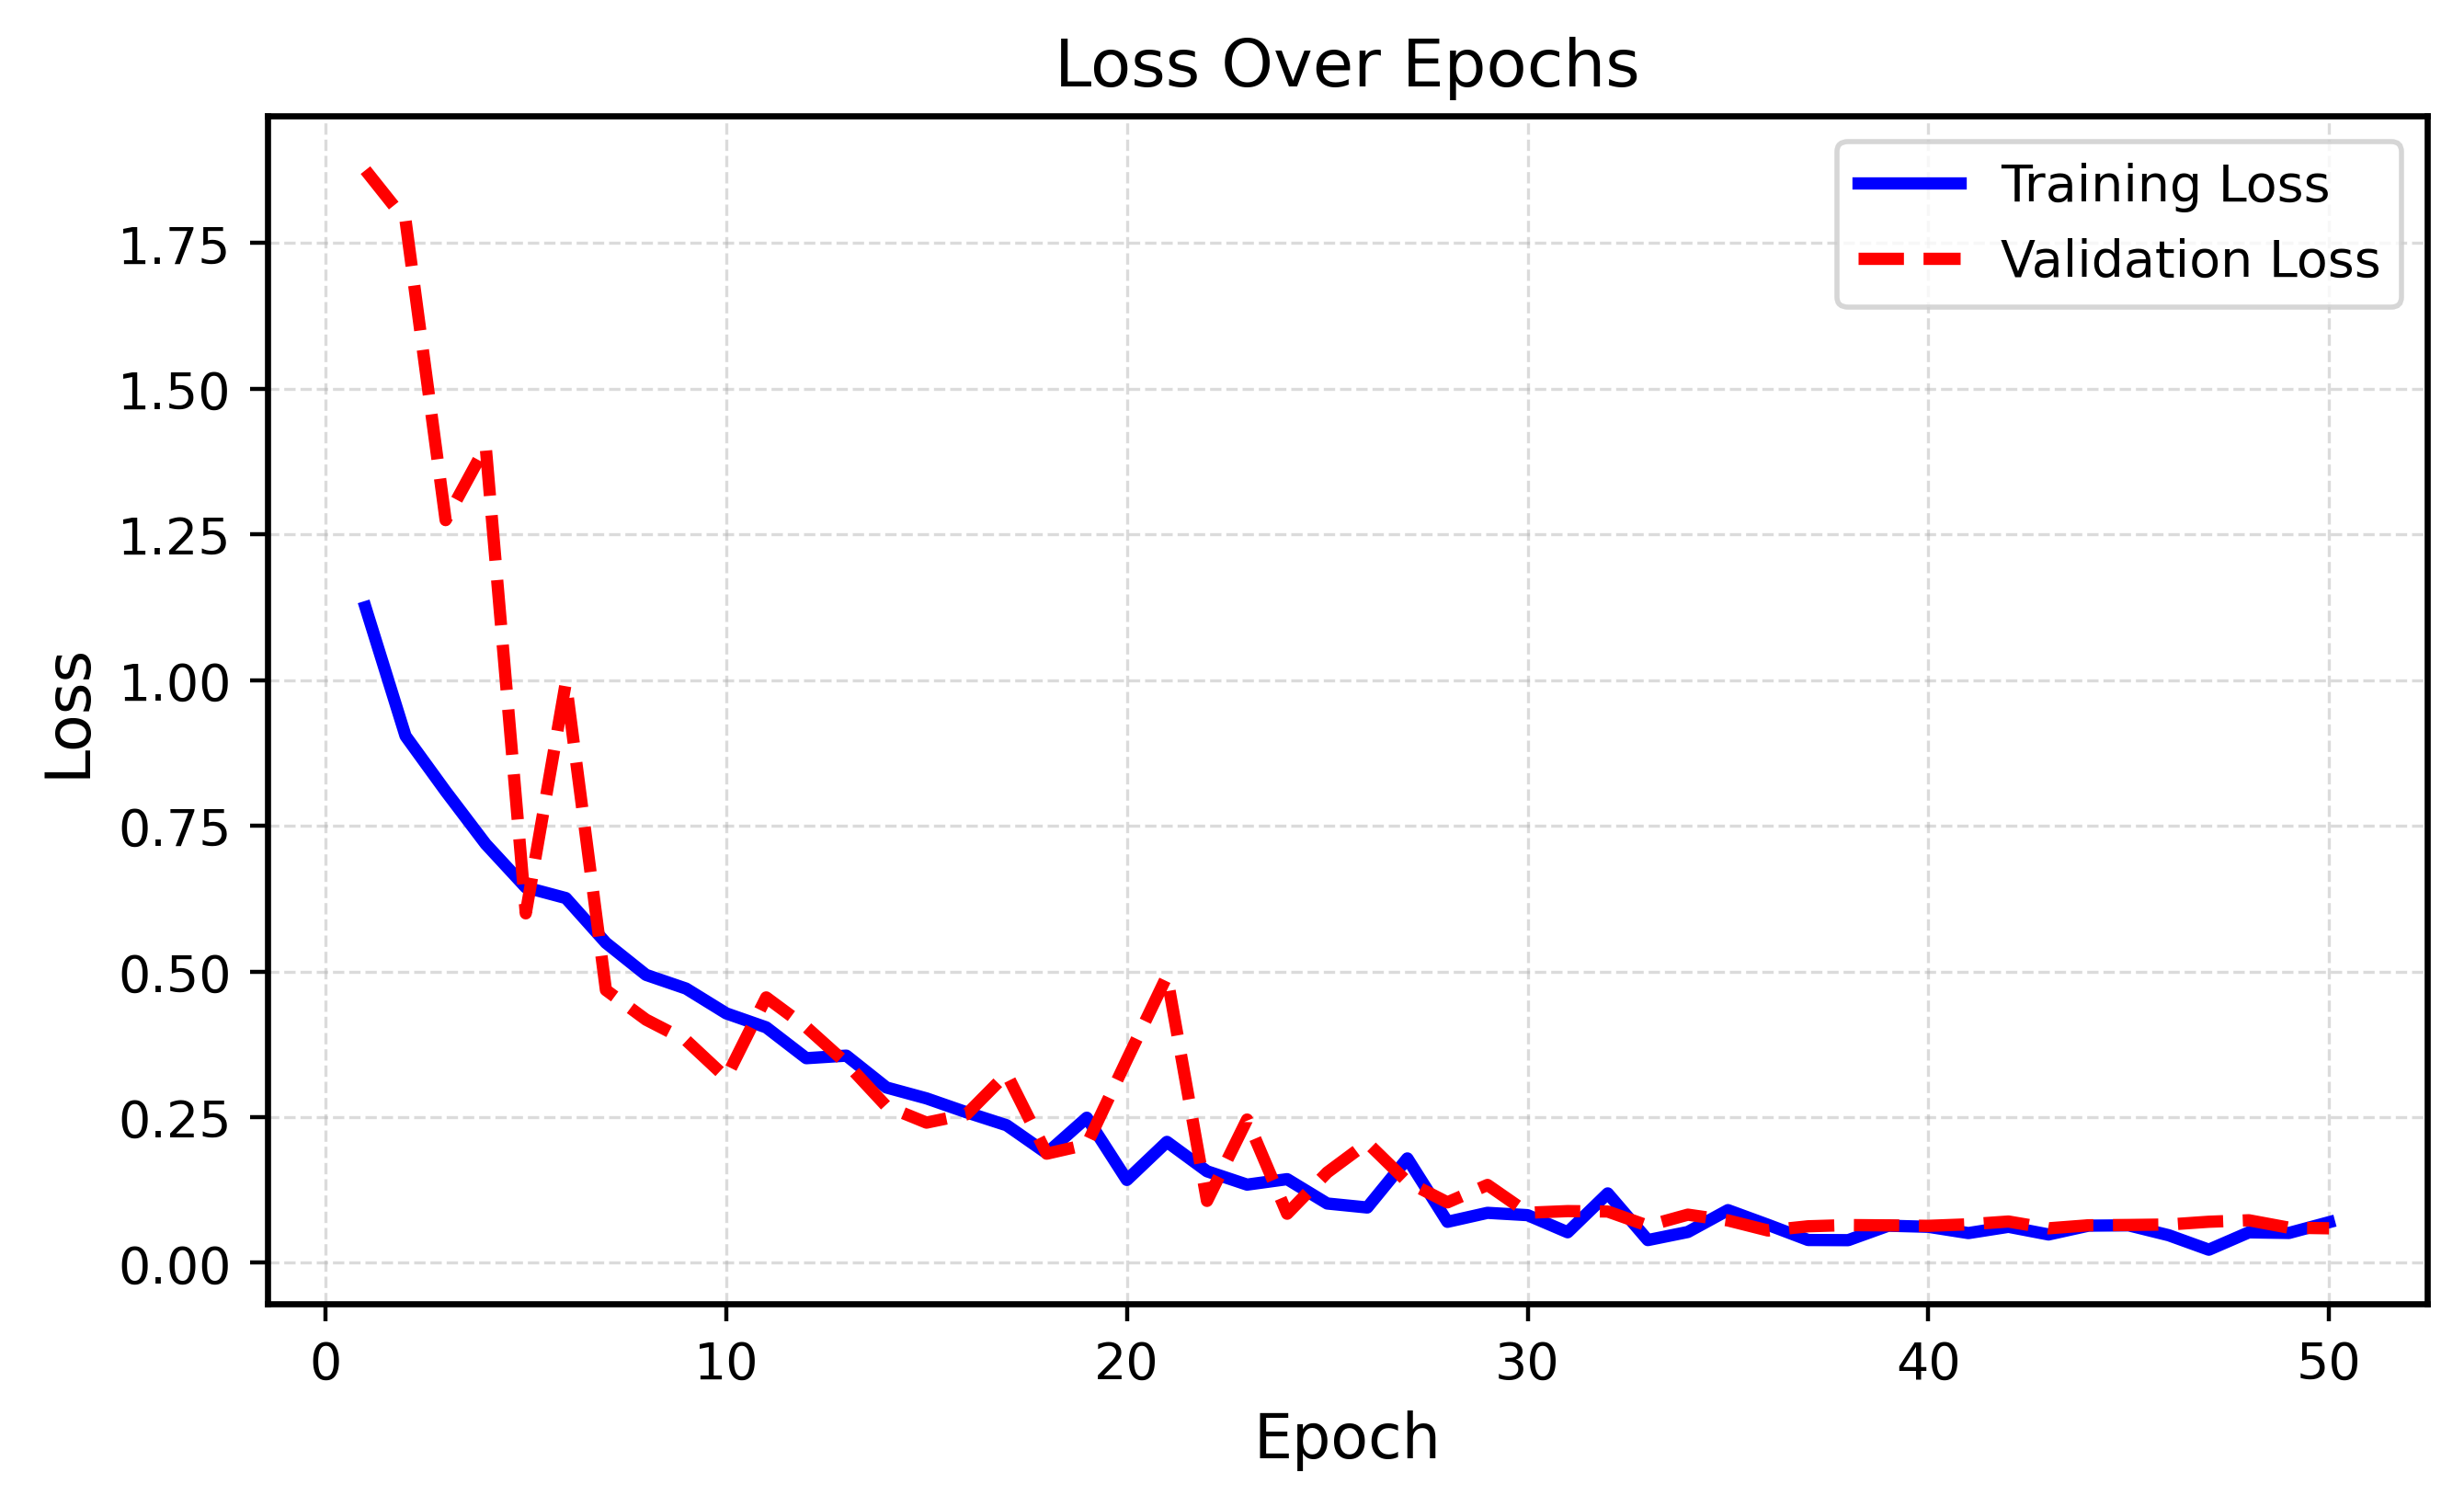

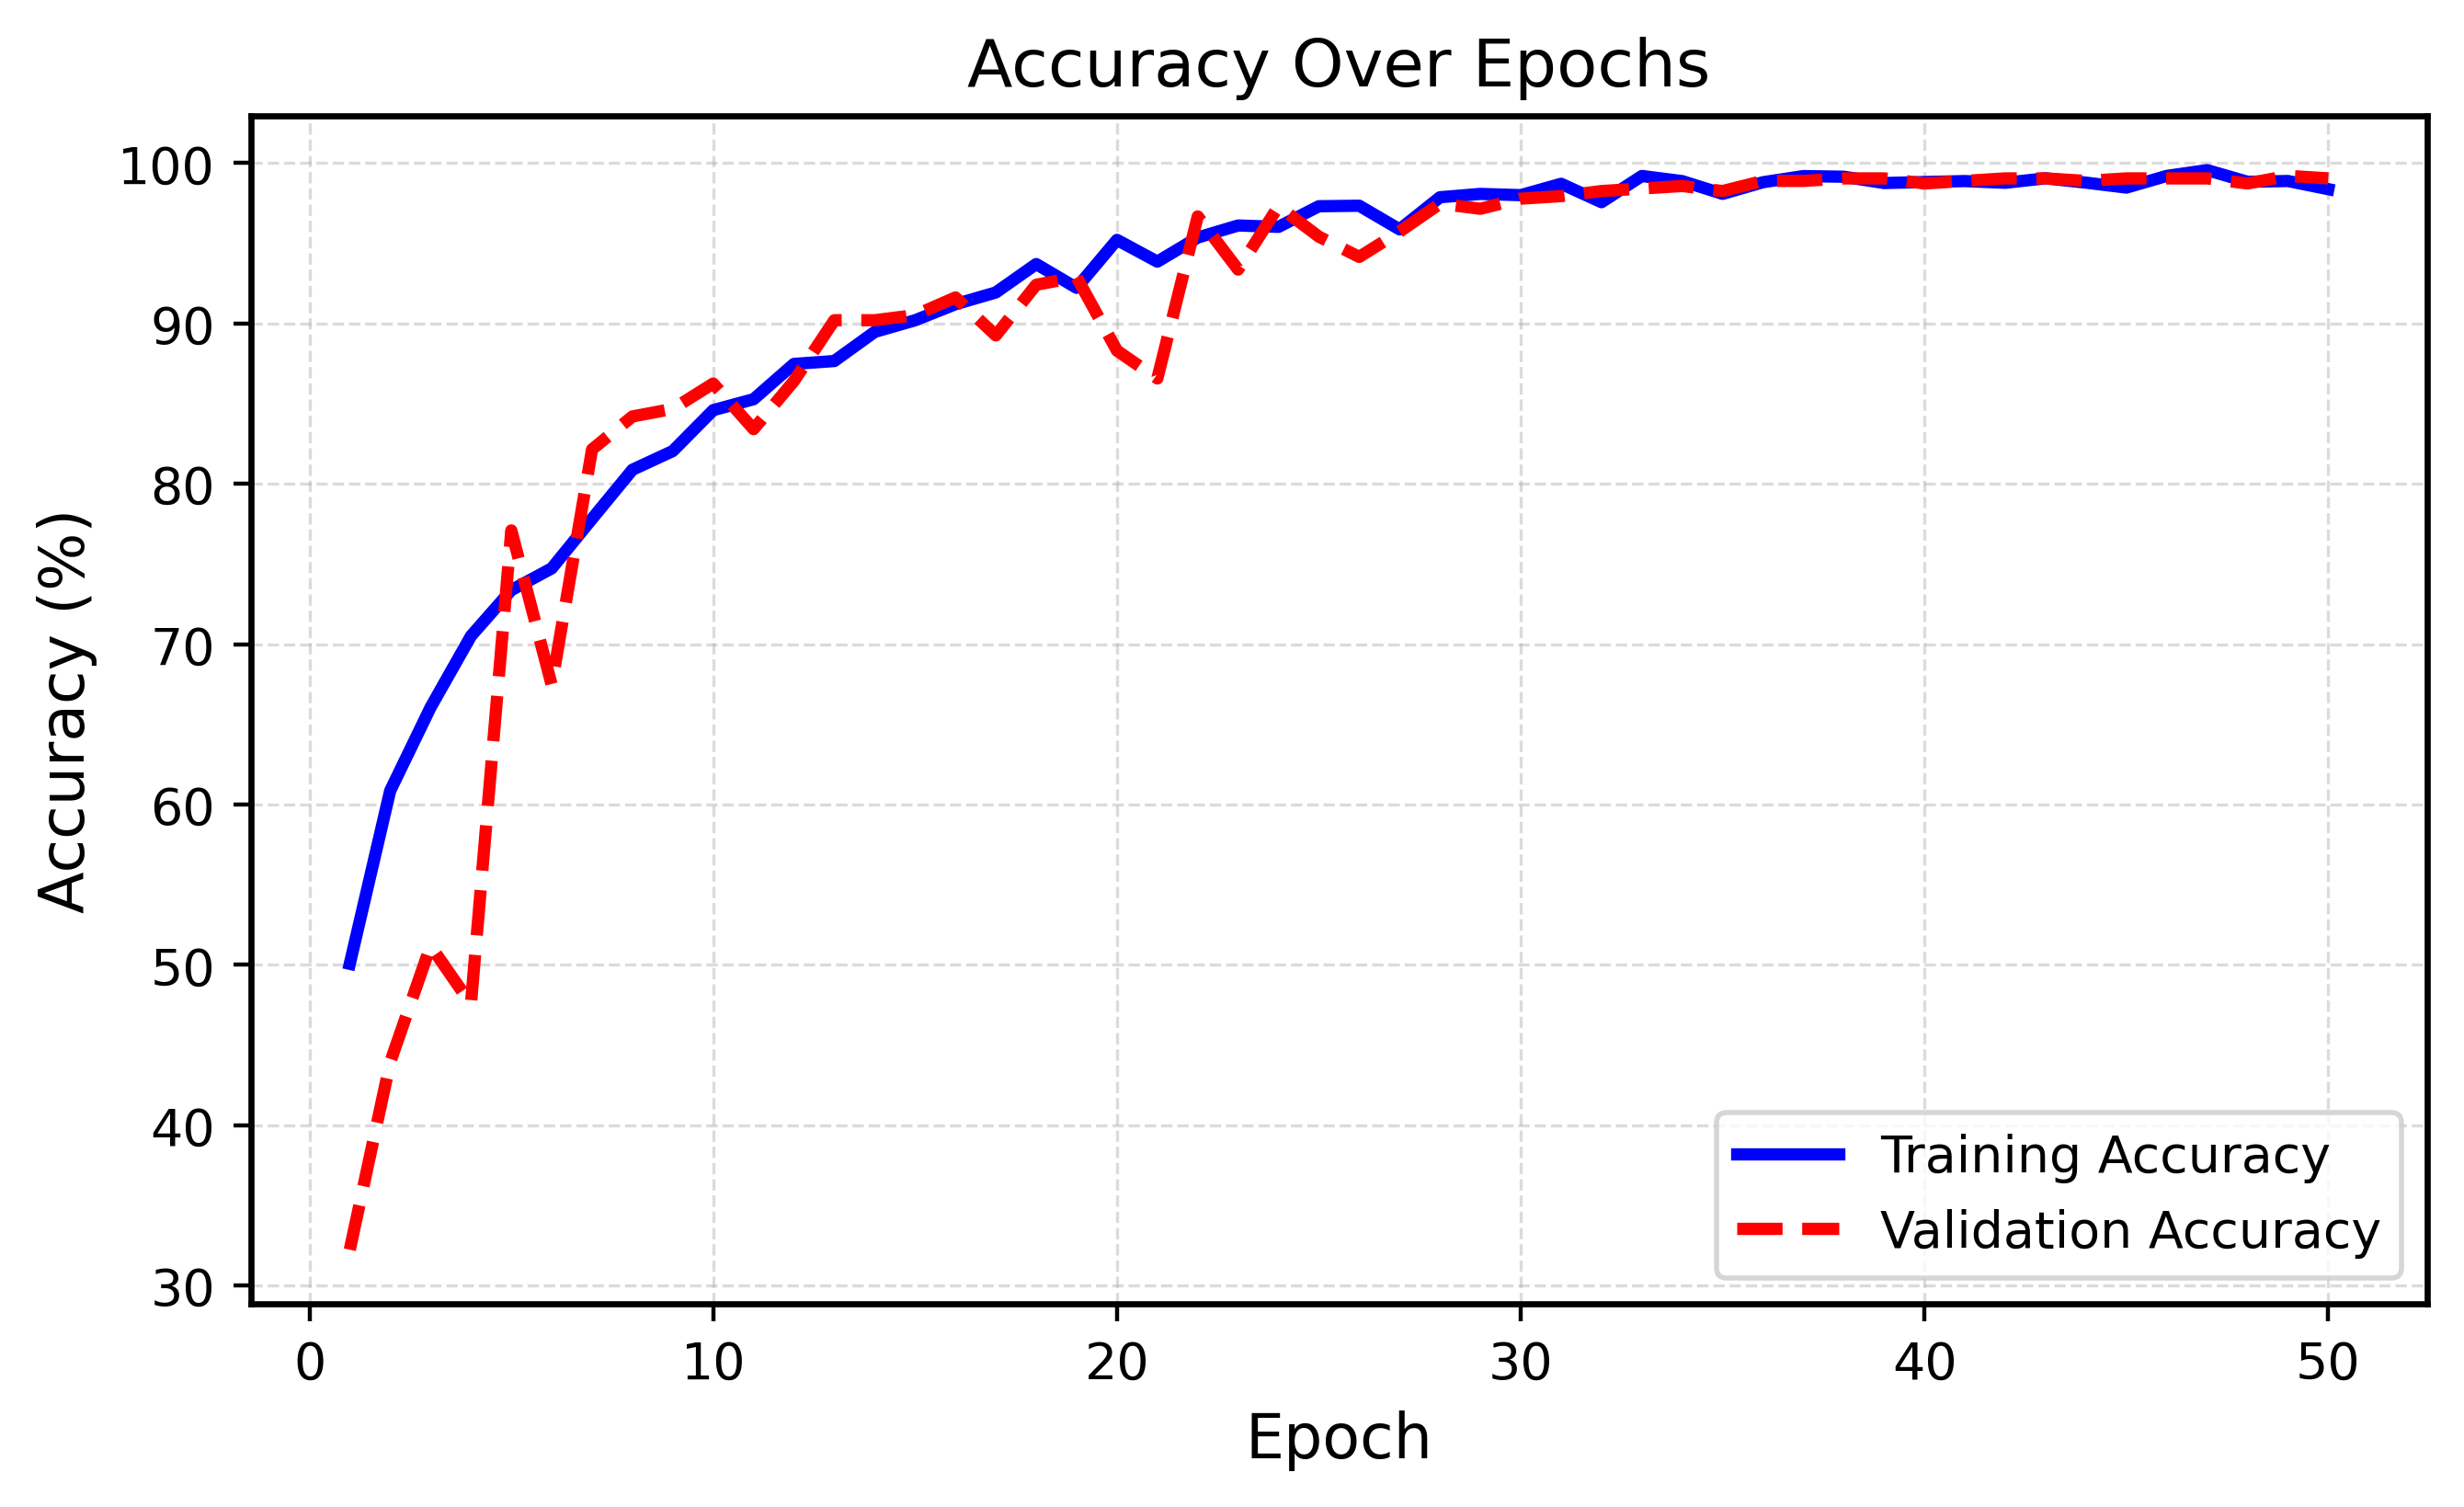

In [ ]:
def plot_training_curves_ieee_blue_red(
    train_loss_history,
    val_loss_history,
    train_acc_history,
    val_acc_history,
    dpi=400,
    save_prefix=None
):
    epochs = np.arange(1, len(train_loss_history) + 1)


    fig1, ax1 = plt.subplots(figsize=(6.8, 4.2), dpi=dpi)

    ax1.plot(
        epochs, train_loss_history,
        label="Training Loss",
        linewidth=2.4,
        color="blue"
    )
    ax1.plot(
        epochs, val_loss_history,
        label="Validation Loss",
        linewidth=2.4,
        linestyle="--",
        color="red"
    )

    ax1.set_title("Loss Over Epochs", fontsize=13)
    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("Loss", fontsize=12)

    ax1.tick_params(axis="both", labelsize=10)
    ax1.grid(True, linestyle="--", linewidth=0.6, alpha=0.45)

    ax1.legend(fontsize=10, frameon=True)

    for spine in ax1.spines.values():
        spine.set_linewidth(1.2)

    fig1.tight_layout()

    if save_prefix:
        fig1.savefig(f"{save_prefix}_loss_curve.png", dpi=dpi, bbox_inches="tight")
        fig1.savefig(f"{save_prefix}_loss_curve.svg", format="svg", bbox_inches="tight")


    plt.show()
    plt.close(fig1)


    fig2, ax2 = plt.subplots(figsize=(6.8, 4.2), dpi=dpi)

    ax2.plot(
        epochs, np.array(train_acc_history) * 100,
        label="Training Accuracy",
        linewidth=2.4,
        color="blue"
    )
    ax2.plot(
        epochs, np.array(val_acc_history) * 100,
        label="Validation Accuracy",
        linewidth=2.4,
        linestyle="--",
        color="red"
    )

    ax2.set_title("Accuracy Over Epochs", fontsize=13)
    ax2.set_xlabel("Epoch", fontsize=12)
    ax2.set_ylabel("Accuracy (%)", fontsize=12)

    ax2.tick_params(axis="both", labelsize=10)
    ax2.grid(True, linestyle="--", linewidth=0.6, alpha=0.45)

    ax2.legend(fontsize=10, frameon=True)

    for spine in ax2.spines.values():
        spine.set_linewidth(1.2)

    fig2.tight_layout()

    if save_prefix:
        fig2.savefig(f"{save_prefix}_accuracy_curve.png", dpi=dpi, bbox_inches="tight")
        fig2.savefig(f"{save_prefix}_accuracy_curve.svg", format="svg", bbox_inches="tight")

    plt.show()
    plt.close(fig2)
plot_training_curves_ieee_blue_red(
    train_loss_history,
    val_loss_history,
    train_acc_history,
    val_acc_history,
    save_prefix="resnet18"
)



================ CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

          F0     1.0000    1.0000    1.0000       212
          F1     0.9885    1.0000    0.9942        86
          F2     1.0000    0.9873    0.9936        79
          F3     1.0000    1.0000    1.0000        86
          F4     1.0000    1.0000    1.0000       170

    accuracy                         0.9984       633
   macro avg     0.9977    0.9975    0.9976       633
weighted avg     0.9984    0.9984    0.9984       633


================ PER-CLASS ACCURACY (Recall) ================
F0                  : 1.0000
F1                  : 1.0000
F2                  : 0.9873
F3                  : 1.0000
F4                  : 1.0000

================ FINAL TEST METRICS ================
Accuracy              : 0.9984
Precision (Macro)     : 0.9977
Recall (Macro)        : 0.9975
F1-score (Macro)      : 0.9976
Specificity (Macro)   : 0.9996
AUC (Macro)           : 1.0000
------

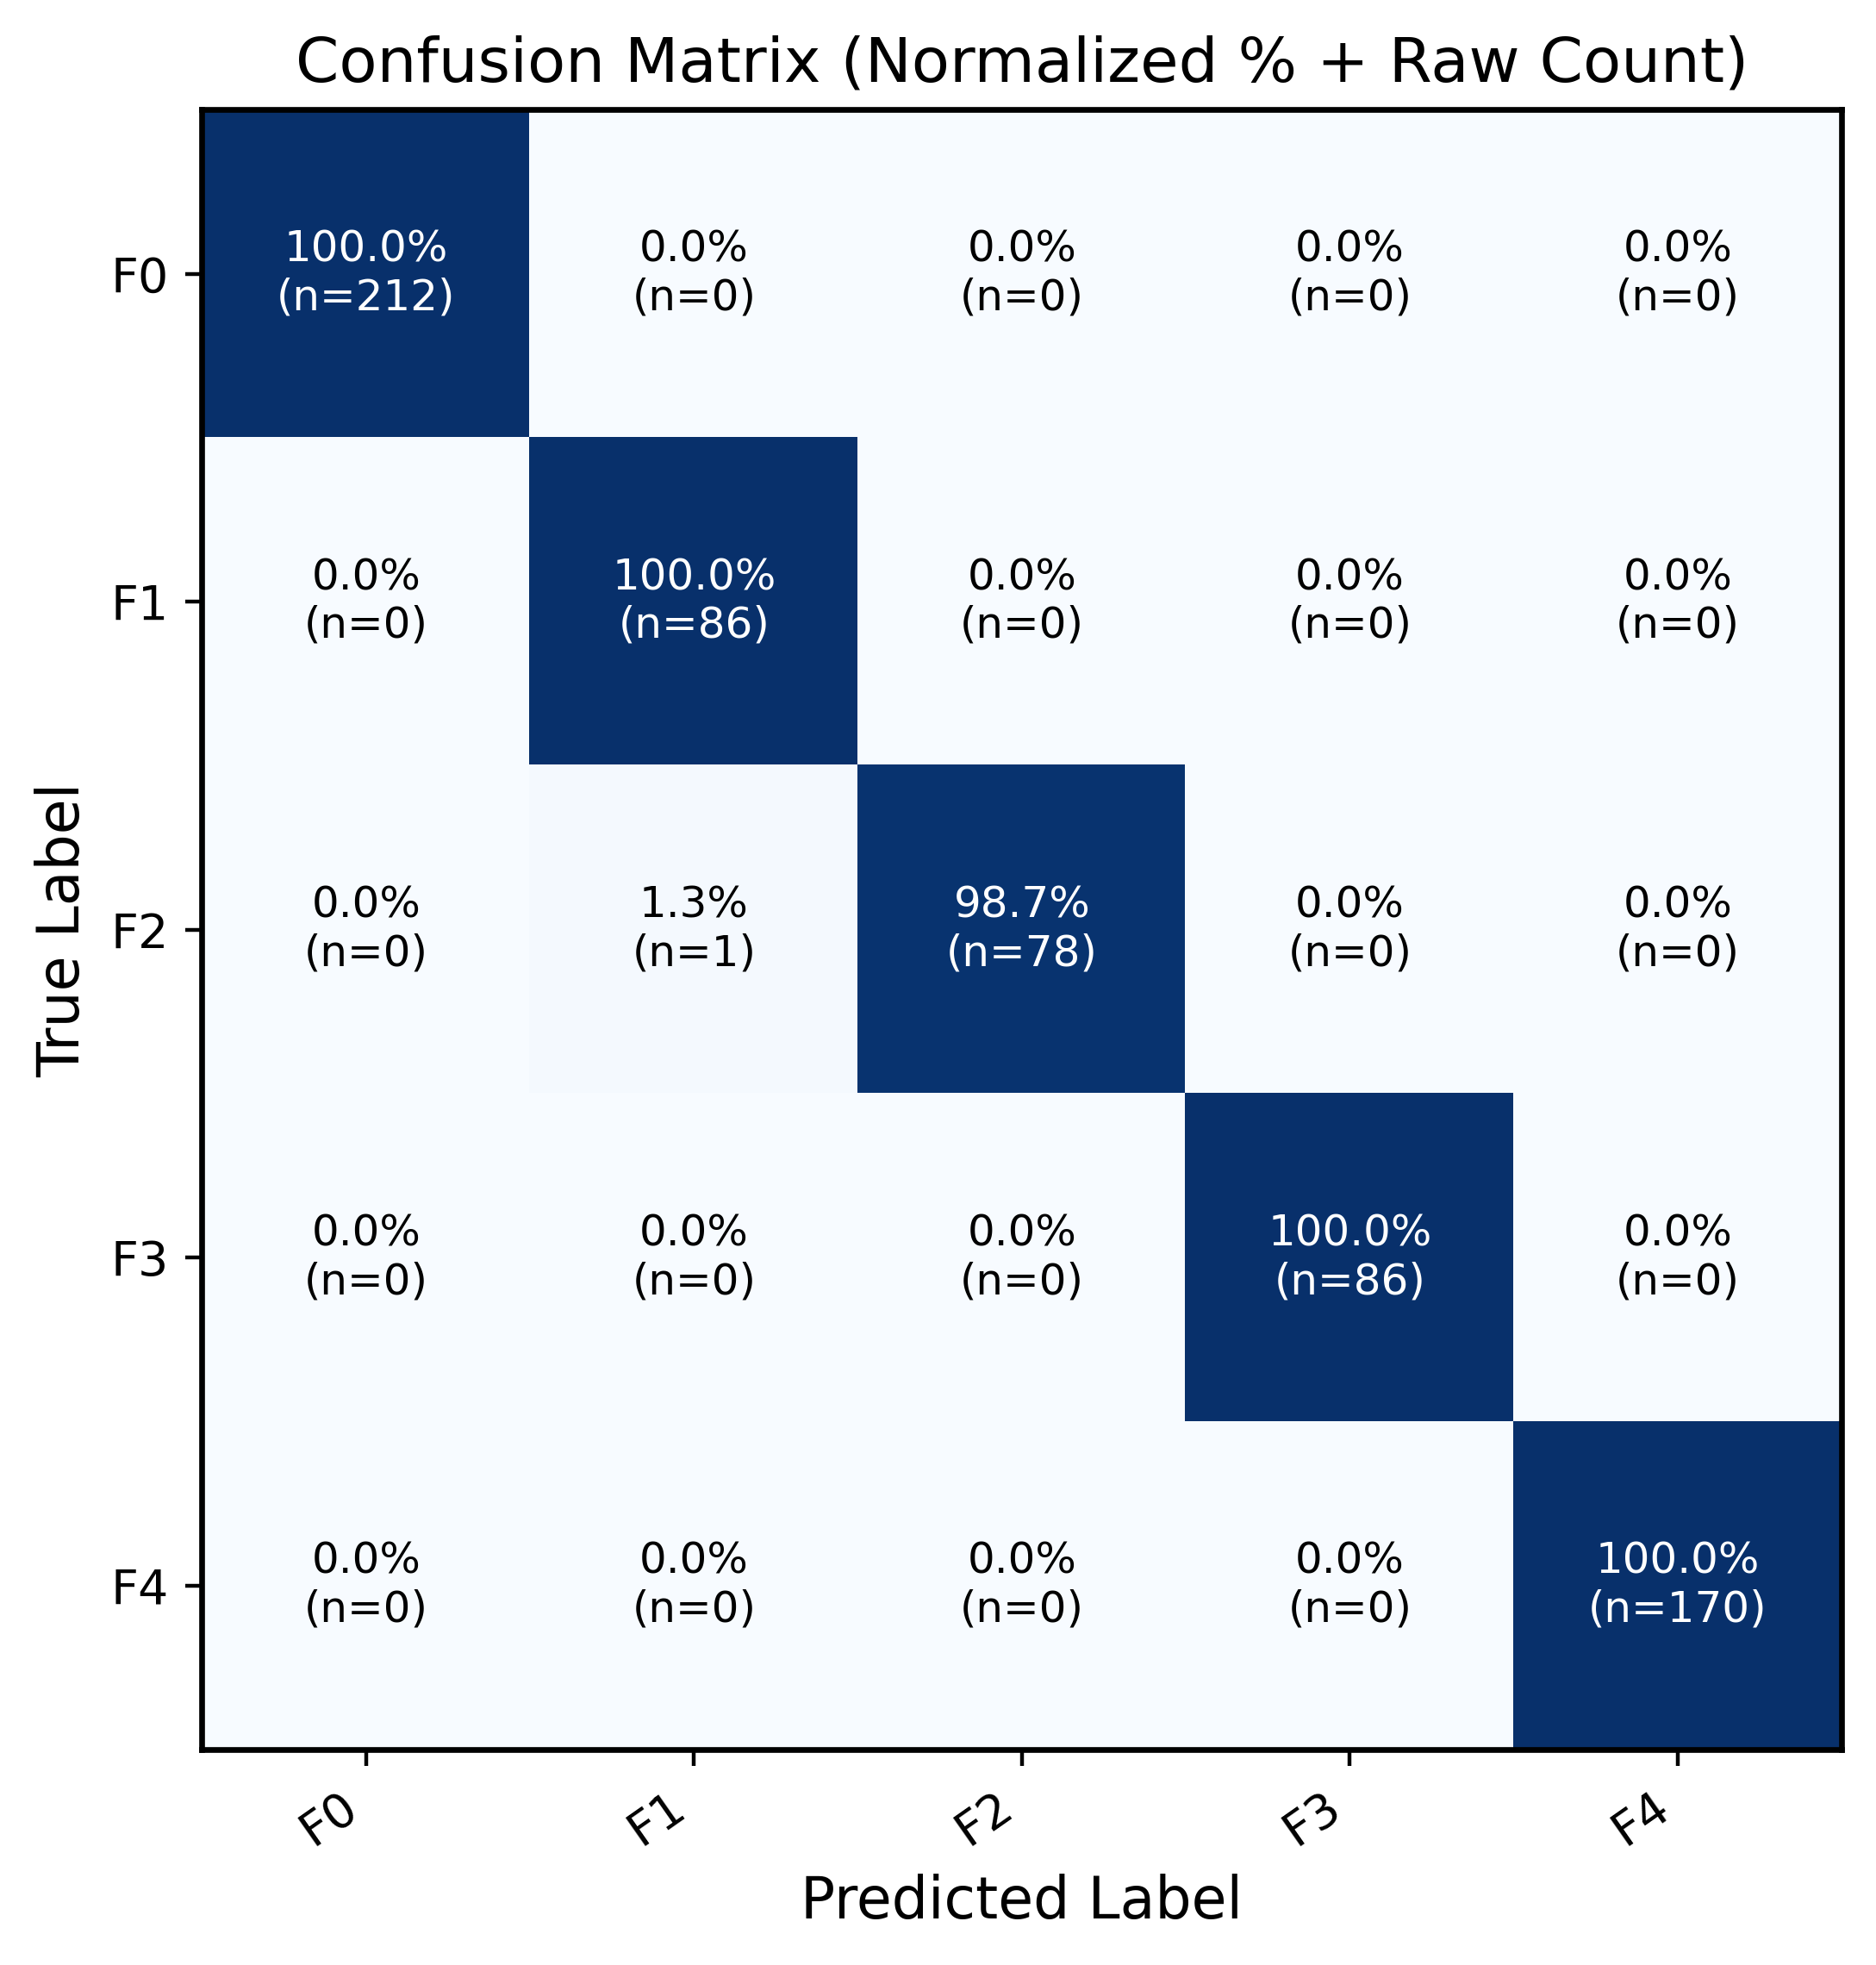

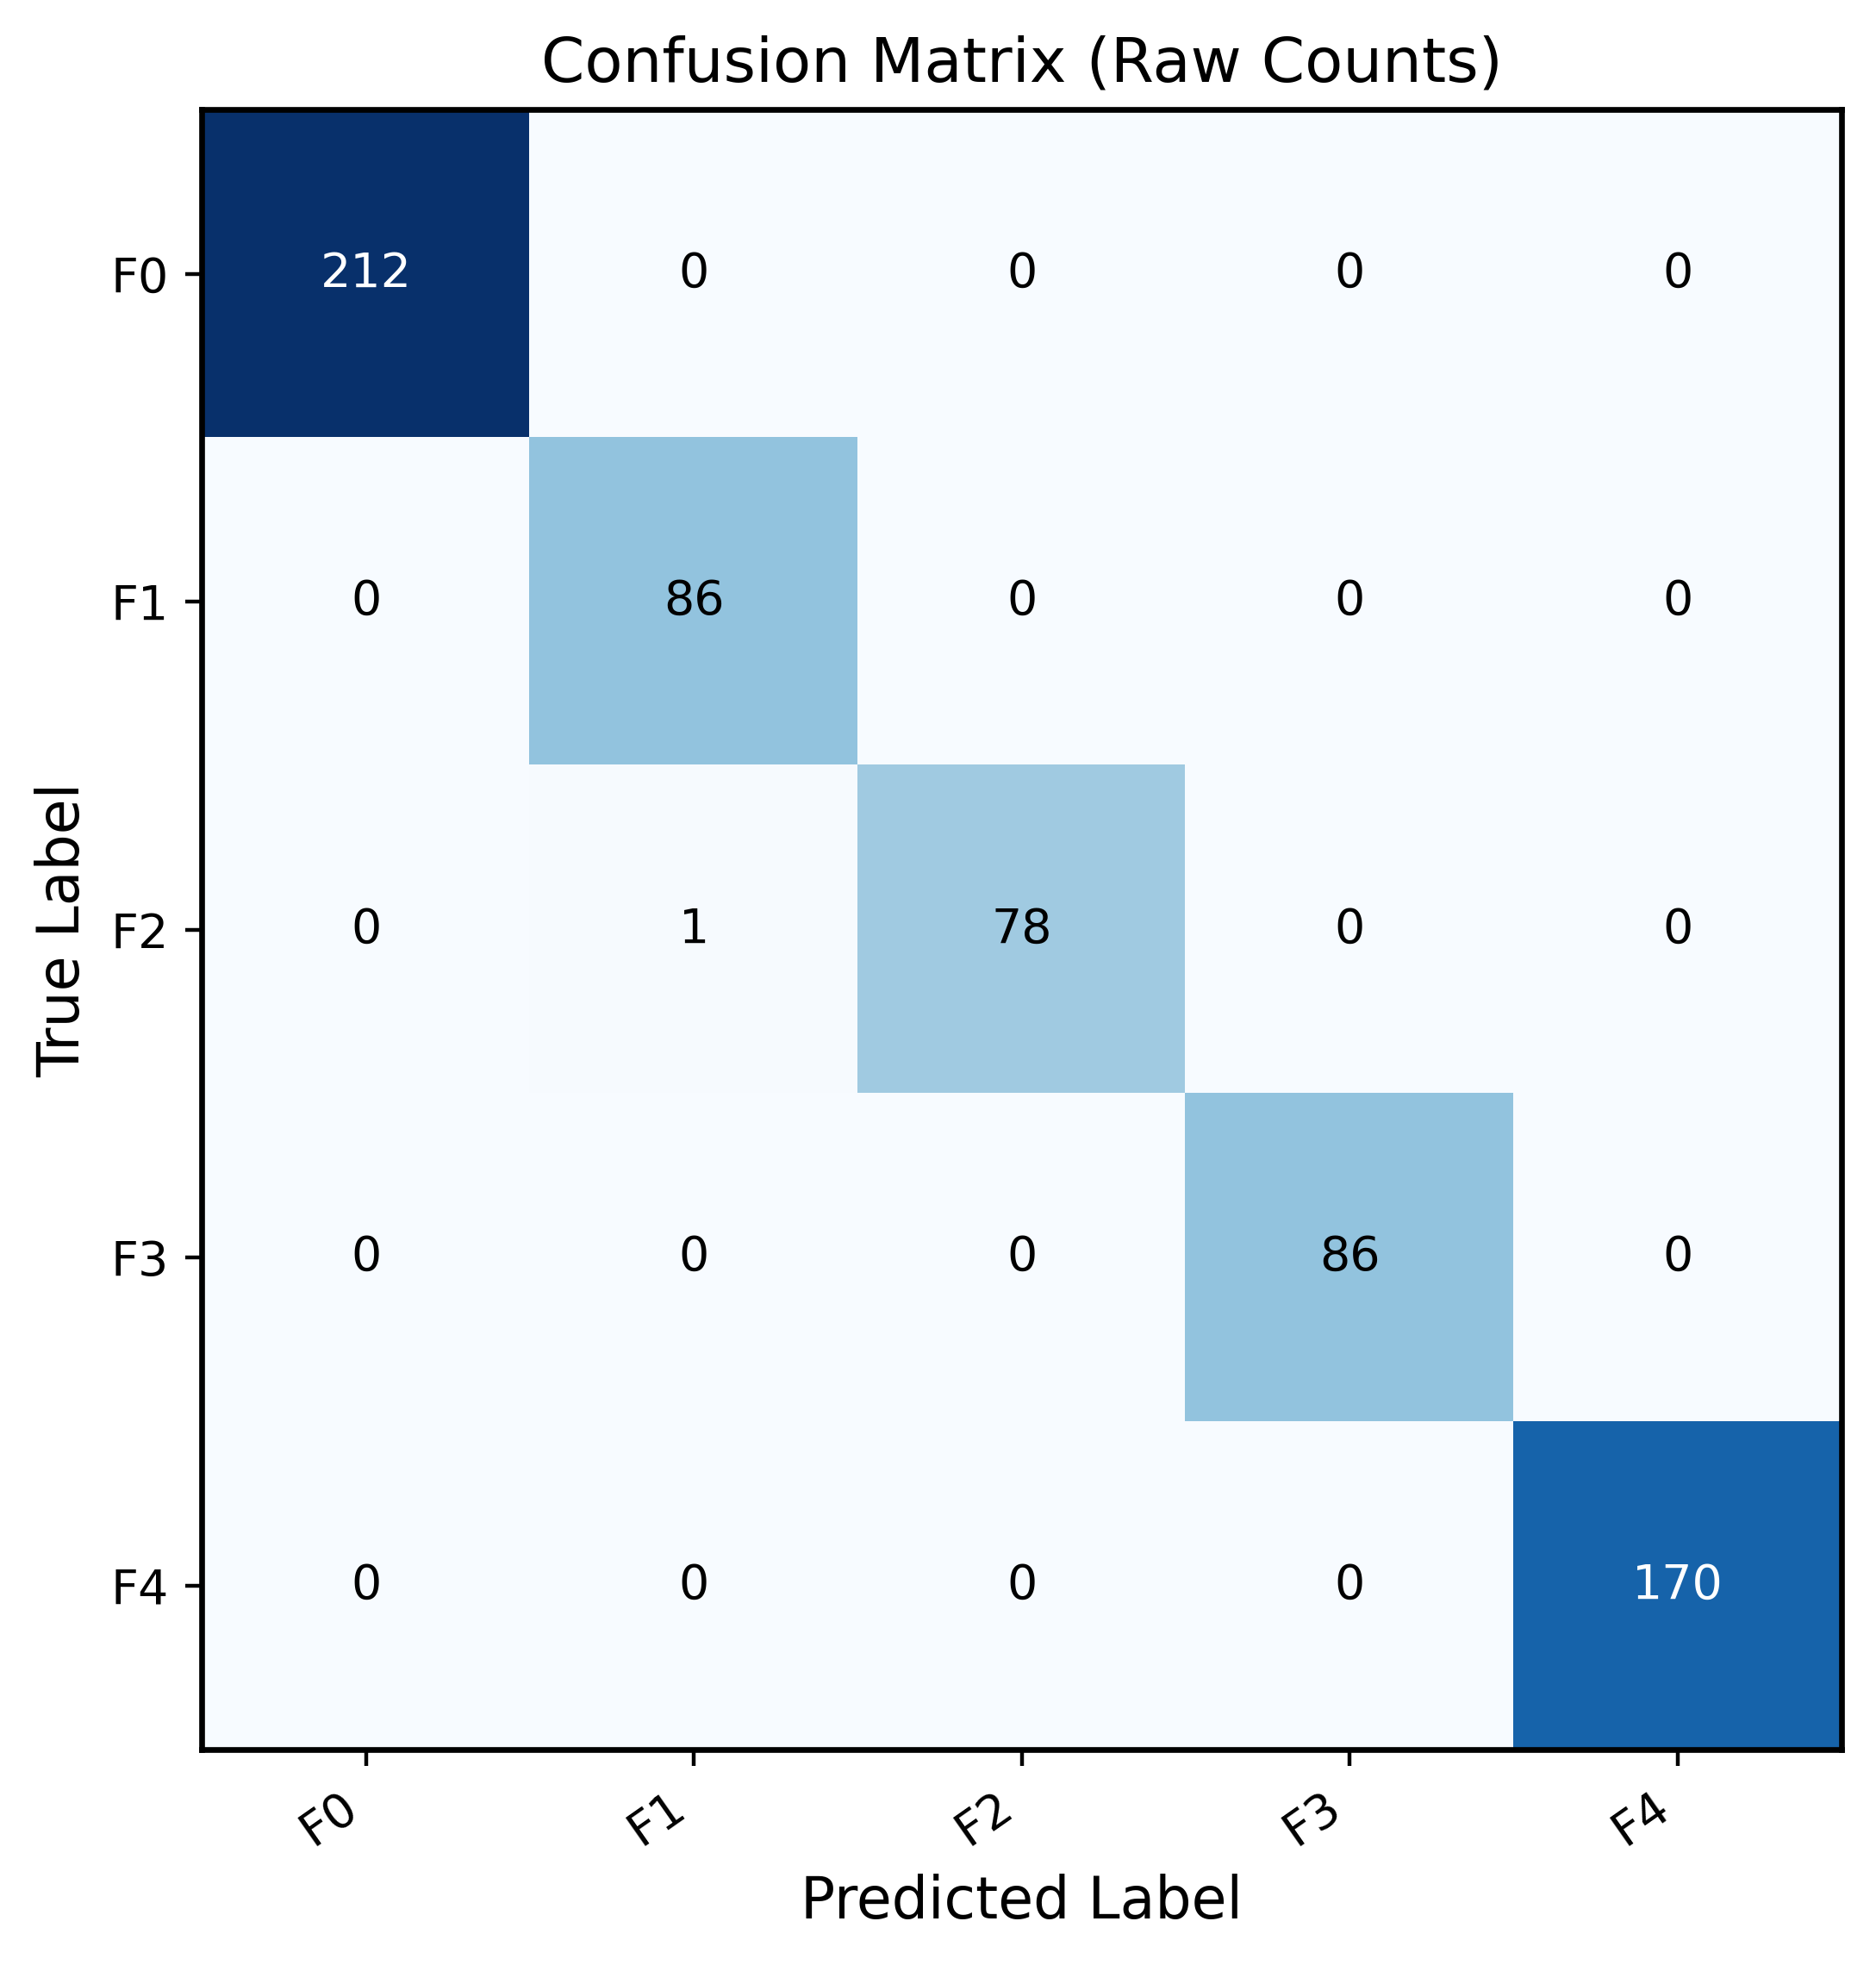

In [ ]:
def save_confusion_matrices_ieee(
    y_true,
    y_pred,
    class_names,
    dpi=400,
    save_prefix=None
):
    cm = confusion_matrix(y_true, y_pred)


    cm_norm = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    fig1, ax1 = plt.subplots(figsize=(6.8, 5.8), dpi=dpi)
    ax1.imshow(cm_norm, interpolation="nearest", cmap="Blues")

    ax1.set_title("Confusion Matrix (Normalized % + Raw Count)", fontsize=13)
    ax1.set_xlabel("Predicted Label", fontsize=12)
    ax1.set_ylabel("True Label", fontsize=12)

    ax1.set_xticks(np.arange(len(class_names)))
    ax1.set_yticks(np.arange(len(class_names)))
    ax1.set_xticklabels(class_names, fontsize=10)
    ax1.set_yticklabels(class_names, fontsize=10)

    plt.setp(ax1.get_xticklabels(), rotation=35, ha="right")

    thresh = cm_norm.max() * 0.55

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            percent = cm_norm[i, j] * 100
            count = cm[i, j]

            ax1.text(
                j, i,
                f"{percent:.1f}%\n(n={count})",
                ha="center", va="center",
                fontsize=9,
                color="white" if cm_norm[i, j] > thresh else "black"
            )

    for spine in ax1.spines.values():
        spine.set_linewidth(1.2)

    fig1.tight_layout()

    if save_prefix:
        fig1.savefig(f"{save_prefix}_confmat_normalized.png", dpi=dpi, bbox_inches="tight")
        fig1.savefig(f"{save_prefix}_confmat_normalized.svg", format="svg", bbox_inches="tight")

    plt.show()
    plt.close(fig1)


    fig2, ax2 = plt.subplots(figsize=(6.8, 5.8), dpi=dpi)
    ax2.imshow(cm, interpolation="nearest", cmap="Blues")

    ax2.set_title("Confusion Matrix (Raw Counts)", fontsize=13)
    ax2.set_xlabel("Predicted Label", fontsize=12)
    ax2.set_ylabel("True Label", fontsize=12)

    ax2.set_xticks(np.arange(len(class_names)))
    ax2.set_yticks(np.arange(len(class_names)))
    ax2.set_xticklabels(class_names, fontsize=10)
    ax2.set_yticklabels(class_names, fontsize=10)

    plt.setp(ax2.get_xticklabels(), rotation=35, ha="right")

    thresh_raw = cm.max() * 0.55

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax2.text(
                j, i,
                f"{cm[i, j]}",
                ha="center", va="center",
                fontsize=10,
                color="white" if cm[i, j] > thresh_raw else "black"
            )

    for spine in ax2.spines.values():
        spine.set_linewidth(1.2)

    fig2.tight_layout()

    if save_prefix:
        fig2.savefig(f"{save_prefix}_confmat_raw.png", dpi=dpi, bbox_inches="tight")
        fig2.savefig(f"{save_prefix}_confmat_raw.svg", format="svg", bbox_inches="tight")

    plt.show()
    plt.close(fig2)



def evaluate_and_save_results(
    model,
    test_loader,
    device,
    checkpoint_path="best_model.pth",
    save_prefix="test"
):

    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()

    y_true, y_pred, y_probs_list = [], [], []


    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs_list.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs_array = np.array(y_probs_list)


    idx_to_label = {v: k for k, v in test_loader.dataset.label_to_idx.items()}
    class_names = [idx_to_label[i] for i in range(len(idx_to_label))]


    cm = confusion_matrix(y_true, y_pred)

    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    per_class_acc = np.nan_to_num(per_class_acc)


    for i, cls in enumerate(class_names):
        print(f"{cls:20s}: {per_class_acc[i]:.4f}")


    accuracy = accuracy_score(y_true, y_pred)

    precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

    precision_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)


    auc_macro, auc_weighted = 0.0, 0.0

    try:
        num_classes = y_probs_array.shape[1]

        if num_classes == 2:
            auc_macro = roc_auc_score(y_true, y_probs_array[:, 1])
            auc_weighted = auc_macro
        else:
            auc_macro = roc_auc_score(y_true, y_probs_array, multi_class="ovr", average="macro")
            auc_weighted = roc_auc_score(y_true, y_probs_array, multi_class="ovr", average="weighted")

    except ValueError as e:
        print(f"\n Warning: Could not calculate AUC due to: {e}")
        auc_macro, auc_weighted = 0.0, 0.0


    specificity_per_class = []

    for i in range(len(cm)):
        tn = cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]
        fp = cm[:, i].sum() - cm[i, i]
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specificity_per_class.append(spec)

    specificity_per_class = np.array(specificity_per_class)

    specificity_macro = float(np.mean(specificity_per_class))

    weights = np.bincount(y_true)
    if len(weights) == len(specificity_per_class) and weights.sum() > 0:
        specificity_weighted = float(np.average(specificity_per_class, weights=weights))
    else:
        specificity_weighted = specificity_macro


    print("\n================ FINAL TEST METRICS ================")
    print(f"Accuracy              : {accuracy:.4f}")

    print(f"Precision (Macro)     : {precision_macro:.4f}")
    print(f"Recall (Macro)        : {recall_macro:.4f}")
    print(f"F1-score (Macro)      : {f1_macro:.4f}")
    print(f"Specificity (Macro)   : {specificity_macro:.4f}")
    print(f"AUC (Macro)           : {auc_macro:.4f}")

    print("-" * 55)

    print(f"Precision (Weighted)  : {precision_weighted:.4f}")
    print(f"Recall (Weighted)     : {recall_weighted:.4f}")
    print(f"F1-score (Weighted)   : {f1_weighted:.4f}")
    print(f"Specificity (Weighted): {specificity_weighted:.4f}")
    print(f"AUC (Weighted)        : {auc_weighted:.4f}")

    print("\nConfusion Matrix (Raw):")
    print(cm)


    save_confusion_matrices_ieee(
        y_true=y_true,
        y_pred=y_pred,
        class_names=class_names,
        save_prefix=save_prefix
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "specificity_macro": specificity_macro,
        "auc_macro": auc_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "specificity_weighted": specificity_weighted,
        "auc_weighted": auc_weighted,
        "per_class_accuracy": per_class_acc,
        "confusion_matrix": cm
    }



metrics = evaluate_and_save_results(
    model=model,
    test_loader=test_loader,
    device=device,
    checkpoint_path="best_model.pth",
    save_prefix="resnet18_test"
)


In [ ]:
test_loader_eva = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=num_workers,
    worker_init_fn=seed_worker,
    generator=g,
    pin_memory=True,
    persistent_workers=True if num_workers > 0 else False
)

In [ ]:
def measure_inference_time(model, dataloader, device, runs=300):
    model.eval()
    # Take one sample
    inputs, _ = next(iter(dataloader))
    inputs = inputs.to(device)

    # Warm-up
    with torch.no_grad():
        for _ in range(50):
            _ = model(inputs)

    torch.cuda.synchronize()
    start = time.time()

    with torch.no_grad():
        for _ in range(runs):
            _ = model(inputs)

    torch.cuda.synchronize()
    end = time.time()

    avg_time_ms = (end - start) / runs * 1000
    return avg_time_ms



num_trials = 10
times = []

for i in range(num_trials):
    t = measure_inference_time(model, test_loader_eva, device, runs=300)
    times.append(t)
    print(f"Trial {i+1}: {t:.4f} ms")

mean_time = np.mean(times)
std_time = np.std(times)
print(f"\nInference Time: {mean_time:.4f} ± {std_time:.4f} ms")


Trial 1: 2.6128 ms
Trial 2: 2.6510 ms
Trial 3: 2.7327 ms
Trial 4: 2.6049 ms
Trial 5: 2.6313 ms
Trial 6: 2.5949 ms
Trial 7: 2.5745 ms
Trial 8: 2.6031 ms
Trial 9: 2.6127 ms
Trial 10: 2.6052 ms

Inference Time: 2.6223 ± 0.0416 ms


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.load_state_dict(
    torch.load("best_model.pth", map_location=device)
)
model.to(device)
model.eval()


ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)


In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self._register_hooks()

    def _register_hooks(self):

        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, target_class):
        self.model.zero_grad()

        output = self.model(input_tensor)
        score = output[:, target_class]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)

        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam

In [ ]:
target_layer = model.layer4[-1]
gradcam = GradCAM(model, target_layer)

In [ ]:
samples = defaultdict(list)
max_samples = 2
num_classes = 5

for inputs, labels in test_loader:
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = model(inputs)
    preds = outputs.argmax(dim=1)

    for i in range(inputs.size(0)):
        
        true_cls = labels[i].item()
        pred_cls = preds[i].item()

        if true_cls == pred_cls:
            if len(samples[true_cls]) < max_samples:
                samples[true_cls].append({
                    "image": inputs[i].unsqueeze(0),
                    "gt": true_cls,
                    "pred": pred_cls
                })


In [ ]:
for cls in samples:
    for item in samples[cls]:
        item["cam"] = gradcam.generate(
            item["image"], target_class=item["pred"]
        )

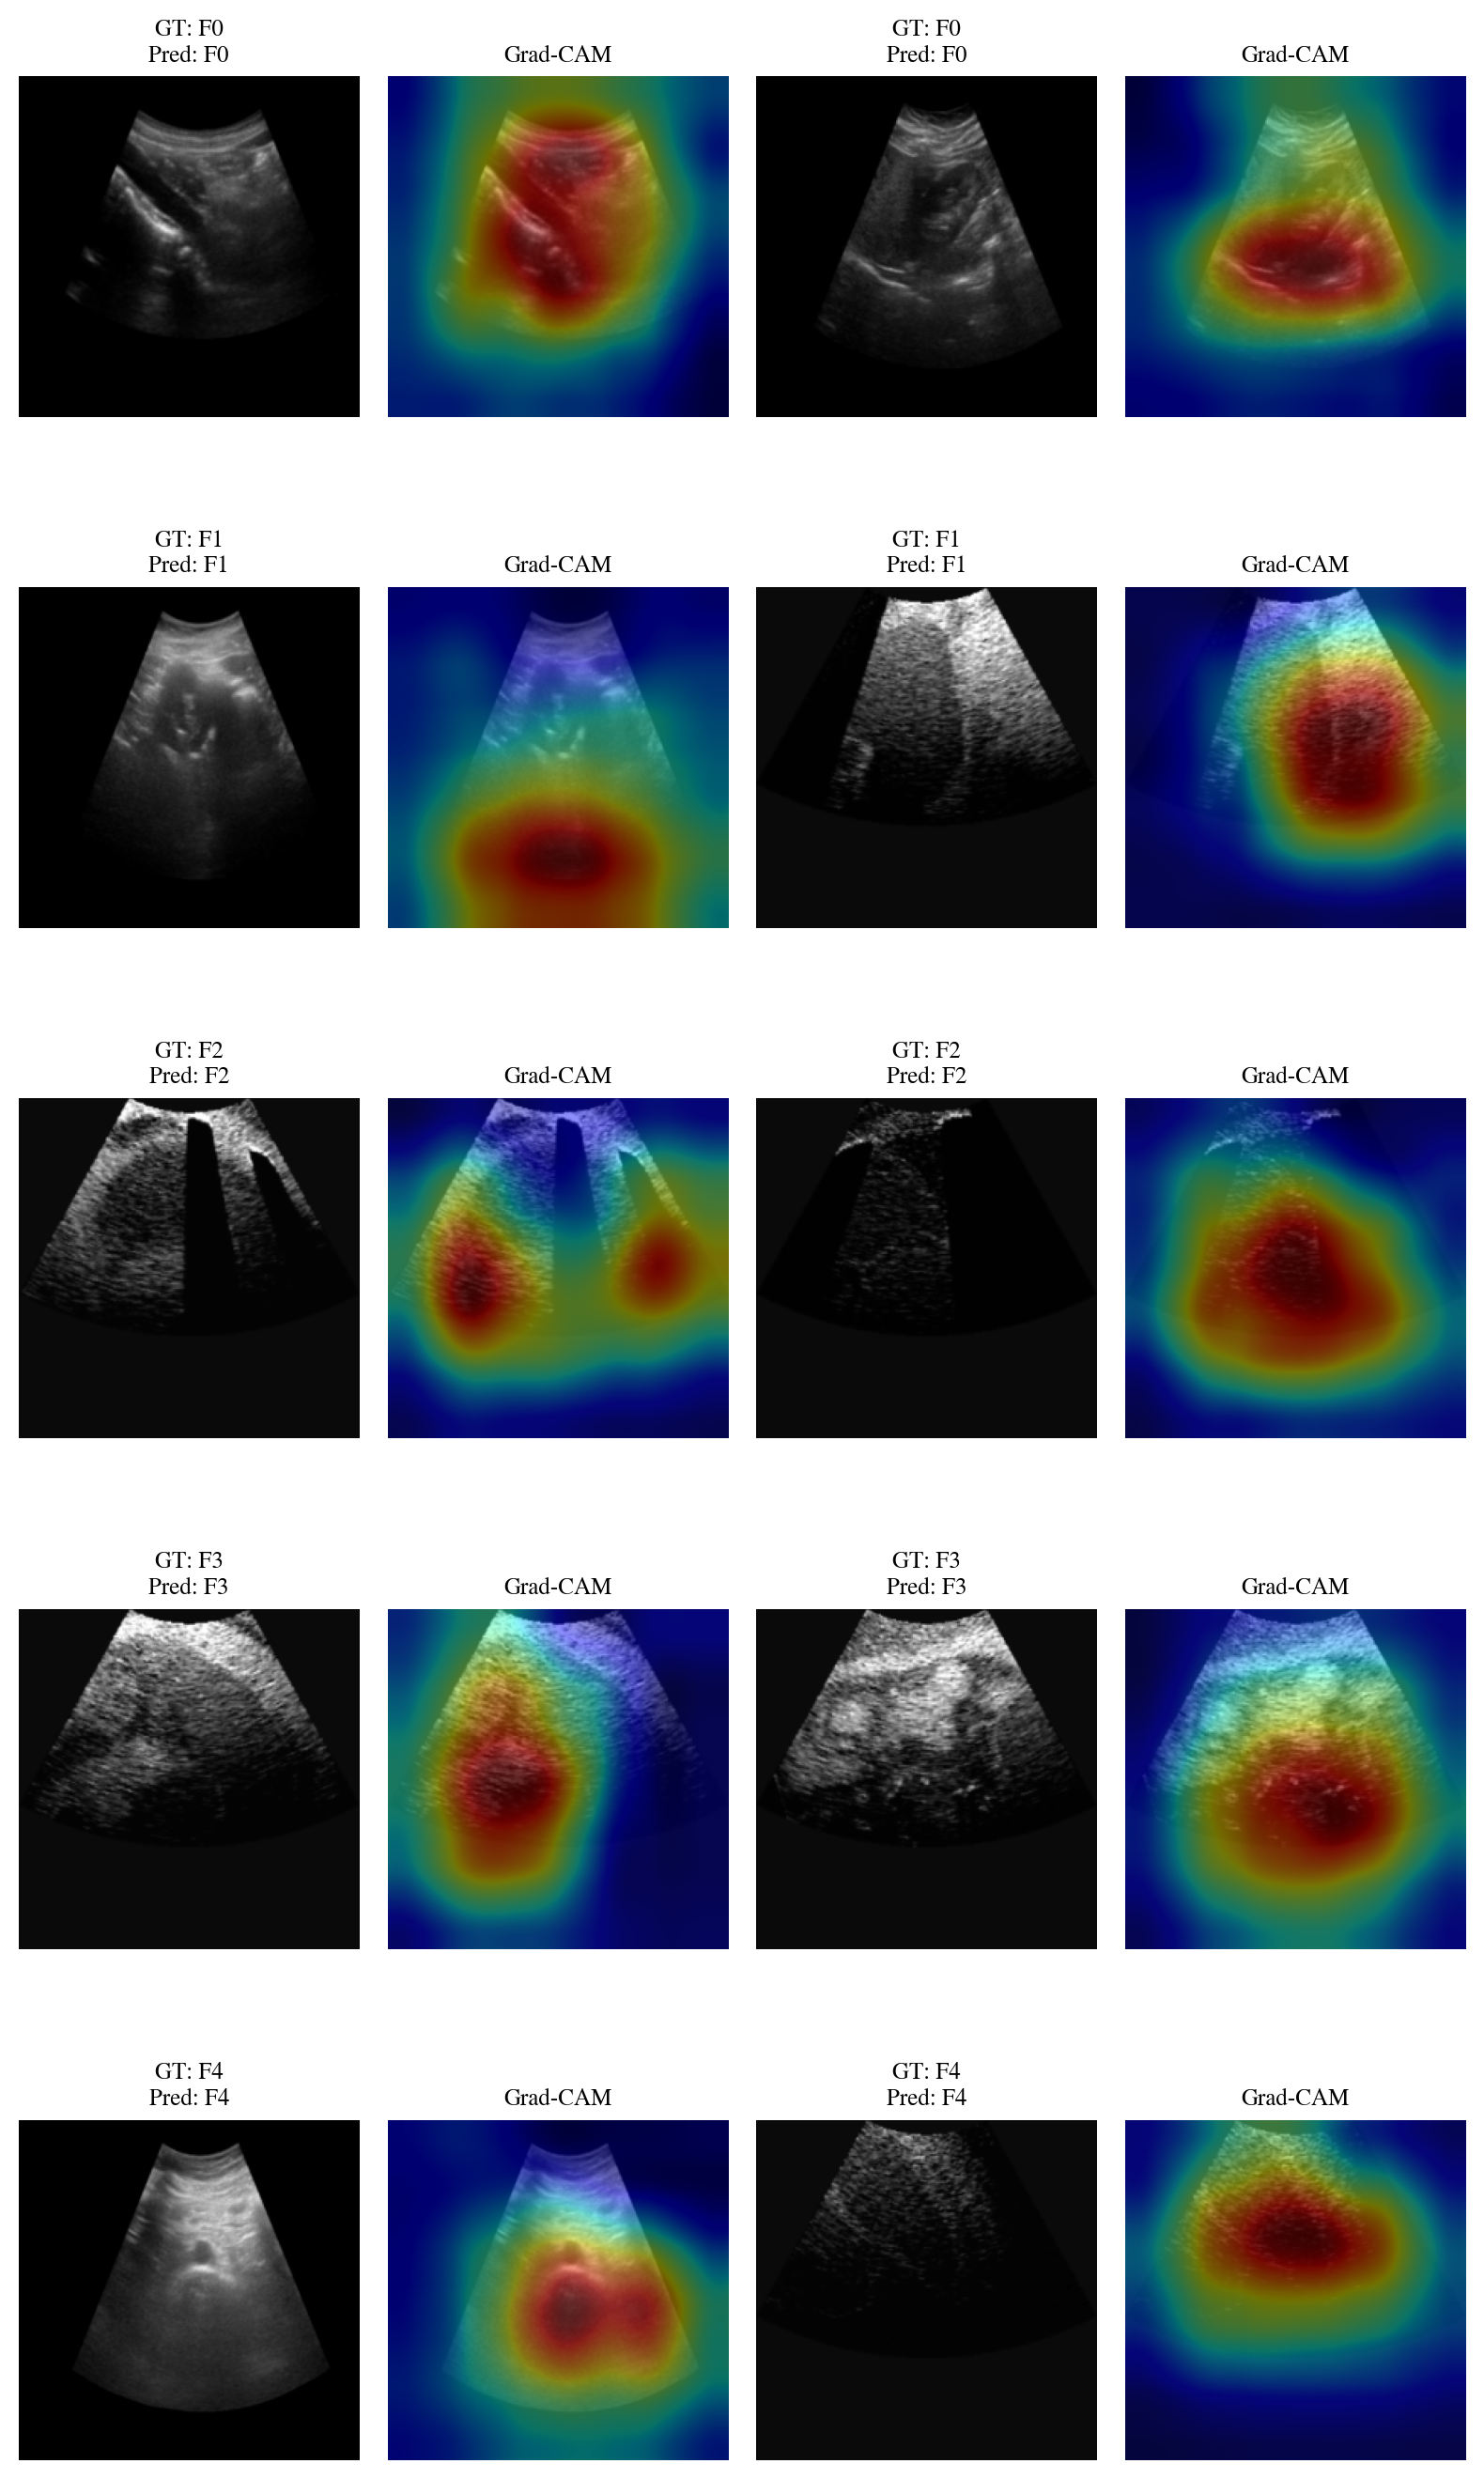

Saved:
results/gradcam_grid.svg
results/gradcam_grid.png


In [ ]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"], 
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

class_names = ['F0', 'F1', 'F2', 'F3', 'F4']
num_classes = len(class_names)
max_samples = 2

save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

fig, axes = plt.subplots(
    num_classes,
    max_samples * 2,
    figsize=(max_samples * 4.0, num_classes * 2.8),
    dpi=200
)


for cls in range(num_classes):

    for j in range(min(max_samples, len(samples[cls]))):
        item = samples[cls][j]

        img = item["image"][0].cpu().permute(1, 2, 0).numpy()

        mean_display = np.array(mean.cpu())
        std_display = np.array(std.cpu())
        img = img * std_display + mean_display
        img = np.clip(img, 0, 1)

        cam = item["cam"][0].cpu().numpy()
        cam = cv2.resize(cam, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_CUBIC)

        col_img = j * 2
        col_cam = j * 2 + 1

   
        axes[cls, col_img].imshow(img)
        axes[cls, col_img].set_title(
            f"GT: {class_names[item['gt']]}\nPred: {class_names[item['pred']]}",
            fontsize=9
        )
        axes[cls, col_img].axis("off")

       
        axes[cls, col_cam].imshow(img)
        axes[cls, col_cam].imshow(cam, cmap="jet", alpha=0.45)
        axes[cls, col_cam].set_title("Grad-CAM", fontsize=9)
        axes[cls, col_cam].axis("off")

    axes[cls, 0].set_ylabel(class_names[cls], fontsize=11)

plt.tight_layout()


svg_path = os.path.join(save_dir, "gradcam_grid.svg")
png_path = os.path.join(save_dir, "gradcam_grid.png")


plt.savefig(svg_path, bbox_inches="tight")


plt.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:")
print(svg_path)
print(png_path)
